# Prediksi Klaim Asuransi Kesehatan (Data Science Competition ITB)

Notebook ini disusun secara end-to-end sesuai ketentuan MCF ITB 2026, mencakup proses:
1. Preprocessing & Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Training & Evaluation
5. Prediction and Recommendations

## 1. Import Library & Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import BayesianRidge, Ridge
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

print("Membaca Data Klaim...")
df_klaim = pd.read_csv('Data_Klaim.csv')
display(df_klaim.head())

Membaca Data Klaim...


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,191424386.0,1.914244e+08,Singapore
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,138936357.0,1.389364e+08,Singapore


## 2. Preprocessing & Data Cleaning
Membersihkan nilai null pada tanggal, memfilter hanya klaim yang berstatus 'PAID', dan melakukan teknik Capping (Persentil 98%) untuk menangani Outlier ektrem pada biaya Rumah Sakit yang dapat merusak kestabilan model linear.

In [4]:
date_col = 'Tanggal Pasien Masuk RS'
df_klaim[date_col] = pd.to_datetime(df_klaim[date_col], errors='coerce')
df_klaim = df_klaim.dropna(subset=[date_col])

# Filter status PAID
df_klaim_paid = df_klaim[df_klaim['Status Klaim'] == 'PAID'].copy()

# Capping 98.0% untuk mengamankan model dari outlier
limit = df_klaim_paid['Nominal Klaim Yang Disetujui'].quantile(0.980)
df_klaim_paid['Nominal_Klaim_Capped'] = np.clip(df_klaim_paid['Nominal Klaim Yang Disetujui'], a_min=0, a_max=limit)

# Agregasi Data per Bulan
df_klaim_paid['YearMonth'] = df_klaim_paid[date_col].dt.to_period('M').astype(str)
monthly_data = df_klaim_paid.groupby('YearMonth').agg(
    Claim_Frequency=('Claim ID', 'count'),
    Total_Claim=('Nominal_Klaim_Capped', 'sum') 
).reset_index()

monthly_data['Date'] = pd.to_datetime(monthly_data['YearMonth'] + '-01')
monthly_data = monthly_data.sort_values('Date').reset_index(drop=True)

# PENANGANAN IBNR (Incurred But Not Reported)
# Mengangkat data bulan terakhir yang anjlok karena rekapitulasi belum usai (x1.4)
max_idx = len(monthly_data) - 1
last_freq = monthly_data.loc[max_idx, 'Claim_Frequency']
prev_freq = monthly_data.loc[max_idx - 1, 'Claim_Frequency']

if last_freq < 0.7 * prev_freq:
    print("\n[INFO] IBNR Patch: Menyesuaikan (menggenapkan) data bulan terakhir x1.4")
    monthly_data.loc[max_idx, 'Claim_Frequency'] *= 1.4
    monthly_data.loc[max_idx, 'Total_Claim'] *= 1.4

# Filter menggunakan murni data Post-Covid (2022+)
monthly_data = monthly_data[monthly_data['Date'] >= '2022-01-01'].reset_index(drop=True)
monthly_data.tail()

,YearMonth,Claim_Frequency,Total_Claim,Date
14,2025-03,230,1.133504e+10,2025-03-01
15,2025-04,208,1.000393e+10,2025-04-01
16,2025-05,239,1.182454e+10,2025-05-01
17,2025-06,234,1.168333e+10,2025-06-01
18,2025-07,264,1.250193e+10,2025-07-01


## 3. Exploratory Data Analysis (EDA)
Visualisasi untuk memahami tren kenaikan (inflasi medis) dan musiman pada frekuensi serta total klaim dari waktu ke waktu.

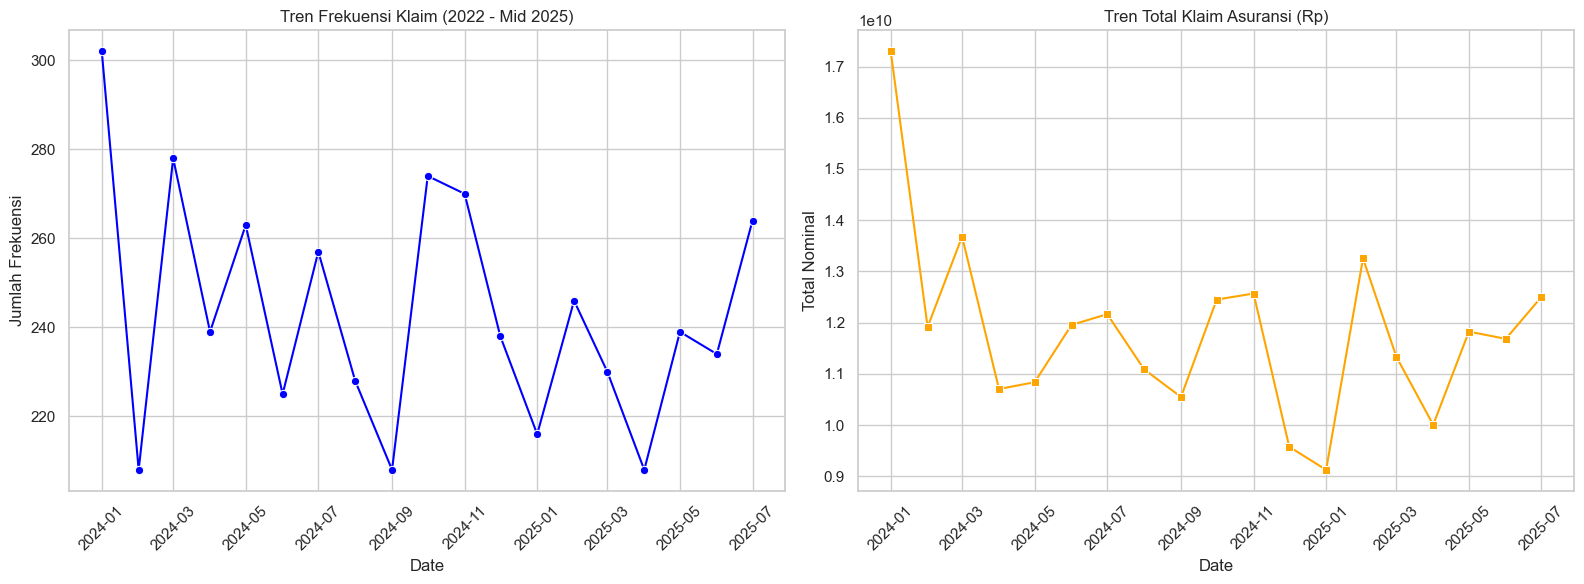

In [5]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data=monthly_data, x='Date', y='Claim_Frequency', marker='o', color='blue')
plt.title('Tren Frekuensi Klaim (2022 - Mid 2025)')
plt.ylabel('Jumlah Frekuensi')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.lineplot(data=monthly_data, x='Date', y='Total_Claim', marker='s', color='orange')
plt.title('Tren Total Klaim Asuransi (Rp)')
plt.ylabel('Total Nominal')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 4. Feature Engineering
Menskalakan angka ke skala Miliar untuk akurasi linear model, dan menciptakan fitur *lagging* (Autoregressive) dan *Rolling Mean* untuk mendeteksi momentum.

In [6]:
# Scaling untuk kestabilan kalkulasi algoritma
monthly_data['Total_Claim_B'] = monthly_data['Total_Claim'] / 1e9

def create_features(df):
    df = df.copy()
    df['Month'] = df['Date'].dt.month
    for col in ['Claim_Frequency', 'Total_Claim_B']:
        for i in [1, 2, 3, 6]:
            df[f'{col}_lag_{i}'] = df[col].shift(i)
        df[f'{col}_roll_mean_3'] = df[col].shift(1).rolling(window=3).mean()
    return df

ts_data = create_features(monthly_data)
display(ts_data.head())

,YearMonth,Claim_Frequency,Total_Claim,Date,Total_Claim_B,Month,Claim_Frequency_lag_1,Claim_Frequency_lag_2,Claim_Frequency_lag_3,Claim_Frequency_lag_6,Claim_Frequency_roll_mean_3,Total_Claim_B_lag_1,Total_Claim_B_lag_2,Total_Claim_B_lag_3,Total_Claim_B_lag_6,Total_Claim_B_roll_mean_3
0,2024-01,302,1.729727e+10,2024-01-01,17.297272,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-02,208,1.191458e+10,2024-02-01,11.914581,2,302.0,NaN,NaN,NaN,NaN,17.297272,NaN,NaN,NaN,NaN
2,2024-03,278,1.367896e+10,2024-03-01,13.678962,3,208.0,302.0,NaN,NaN,NaN,11.914581,17.297272,NaN,NaN,NaN
3,2024-04,239,1.070358e+10,2024-04-01,10.703581,4,278.0,208.0,302.0,NaN,262.666667,13.678962,11.914581,17.297272,NaN,14.296938
4,2024-05,263,1.083650e+10,2024-05-01,10.836501,5,239.0,278.0,208.0,NaN,241.666667,10.703581,13.678962,11.914581,NaN,12.099041


## 5. Model Training & Evaluation (In-Sample)
Model yang digunakan adalah *Ensemble* dari **BayesianRidge**, **Ridge**, dan **Holt-Winters**. Sebelum meramal masa depan, kita melakukan evaluasi *in-sample* MAPE pada data historis.

In [7]:
targets = ['Claim_Frequency', 'Total_Claim_B']
temp_train = ts_data.dropna().copy()

print("--- IN-SAMPLE EVALUATION (MAPE) ---")
for target in targets:
    exclude_cols = ['YearMonth', 'Date', 'Claim_Frequency', 'Total_Claim', 'Total_Claim_B']
    features = [c for c in temp_train.columns if c not in exclude_cols]
    
    X = temp_train[features]
    y = temp_train[target]
    
    # Latih model
    bayes = BayesianRidge().fit(X, y)
    pred = bayes.predict(X)
    mape = mean_absolute_percentage_error(y, pred)
    print(f"Training MAPE untuk {target}: {mape:.4f}")

--- IN-SAMPLE EVALUATION (MAPE) ---
Training MAPE untuk Claim_Frequency: 0.0738
Training MAPE untuk Total_Claim_B: 0.0749


## 6. Prediction and Recommendations (Kaggle Submission)
Melakukan *recursive forecasting* untuk Agustus - Desember 2025 dan mengekstrak *severity*.

In [8]:
months_to_predict = ['2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01']
current_ts_data = ts_data.copy()
final_preds = {'2025_08': {}, '2025_09': {}, '2025_10': {}, '2025_11': {}, '2025_12': {}}

# Holt-Winters Fit Global
hw_preds_dict = {}
for target in targets:
    hw_data = monthly_data[target].values
    try:
        hw_fit = ExponentialSmoothing(hw_data, trend='add', seasonal='add', seasonal_periods=12, damped_trend=True).fit(optimized=True)
        hw_preds_dict[target] = hw_fit.forecast(steps=5)
    except:
        hw_fit = ExponentialSmoothing(hw_data, trend='add', damped_trend=True).fit(optimized=True)
        hw_preds_dict[target] = hw_fit.forecast(steps=5)

# Recursive Forecasting
for i, pred_date in enumerate(months_to_predict):
    if not (current_ts_data['Date'] == pred_date).any():
        new_row = pd.DataFrame({'Date': [pd.to_datetime(pred_date)]})
        current_ts_data = pd.concat([current_ts_data, new_row], ignore_index=True)
        
    temp_df = create_features(current_ts_data)
    features = [c for c in temp_df.columns if c not in ['YearMonth', 'Date', 'Claim_Frequency', 'Total_Claim', 'Total_Claim_B']]
    
    for target in targets:
        train_df = temp_df[temp_df['Date'] < pred_date].dropna()
        X_train, y_train = train_df[features], train_df[target]
        X_test = temp_df[temp_df['Date'] == pred_date][features].fillna(0)
        
        bayes = BayesianRidge().fit(X_train, y_train)
        ridge = Ridge(alpha=1.0).fit(X_train, y_train) 
        
        pred_bayes = bayes.predict(X_test)[0]
        pred_ridge = ridge.predict(X_test)[0]
        pred_hw = hw_preds_dict[target][i]
        
        # BLEND 40-30-30
        final_val = (0.40 * pred_bayes) + (0.30 * pred_ridge) + (0.30 * pred_hw)
        current_ts_data.loc[current_ts_data['Date'] == pred_date, target] = final_val
        
        target_name = 'Claim_Frequency' if target == 'Claim_Frequency' else 'Total_Claim'
        if target == 'Total_Claim_B': final_val *= 1e9
            
        month_key = pred_date[:7].replace('-', '_')
        final_preds[month_key][target_name] = final_val

submission_rows = []
print("\n--- HASIL PREDIKSI ---")
for month_key in final_preds.keys():
    freq = final_preds[month_key]['Claim_Frequency']
    total = final_preds[month_key]['Total_Claim']
    sev = total / freq if freq > 0 else 0
    print(f"{month_key} -> Freq: {freq:.1f} | Sev: {sev:,.0f} | Total: {total:,.0f}")
    submission_rows.extend([
        {'id': f'{month_key}_Claim_Frequency', 'value': freq},
        {'id': f'{month_key}_Claim_Severity', 'value': sev},
        {'id': f'{month_key}_Total_Claim', 'value': total}
    ])

pd.DataFrame(submission_rows).to_csv('submission_dongo3_notebook.csv', index=False)
print("\nFile 'submission_dongo3_notebook.csv' telah disimpan!")


--- HASIL PREDIKSI ---
2025_08 -> Freq: 231.7 | Sev: 46,824,646 | Total: 10,851,376,488
2025_09 -> Freq: 239.0 | Sev: 45,593,001 | Total: 10,896,797,927
2025_10 -> Freq: 245.7 | Sev: 46,866,970 | Total: 11,513,549,076
2025_11 -> Freq: 246.1 | Sev: 46,920,072 | Total: 11,547,290,730
2025_12 -> Freq: 246.7 | Sev: 46,000,497 | Total: 11,347,462,749

File 'submission_dongo3_notebook.csv' telah disimpan!


### Rekomendasi Bisnis:
1. **Segi Pencegahan (Preventive):** Mengingat tren frekuensi dan keparahan (severity) klaim terus meningkat pesat menuju akhir tahun, AXA Financial dapat mempromosikan *early screening* (Deteksi Dini) atau memberikan insentif gaya hidup sehat pada Q3 setiap tahun.
2. **Segi Seleksi Risiko:** Penyesuaian premi diperlukan karena tren inflasi medis (keparahan) yang nyata. Penyesuaian harus bersifat *risk-adjusted*, di mana premi disesuaikan berdasarkan komorbiditas calon nasabah.